# Kapitel 2 - Ett ML projekt från början till slut

## Faktafrågor

1. 
ett, indentifera problemt, att förstå vad ska man göra, hur kan man lösa det på bästa sättet.

två, att hämta data, från api, eller csv eller nån annanstans. att forska och se om det finns data, är det lagligt att använda den datan osv. 

tre, att utförska datan, göra en EDA för att se vad som finns i datan och förstå sig på datan.

fyra, att bearbeta datan, till exemple rensa om det behövs genom att bort onädiga kolumner och null data och icke numeriska data, om vi kan göra feature engenering.

fem, välja modell, här väljer vi vilken modell som skulle kunna passa för vår data. man kan testa flera olika modeller tills man har hittat den bästa modellen. 

sex, fin justera modellen och presentera inför rätt mål grupp och eventulat tänkta på vad man kan göra för att få folk utanför domainet att förstå det man vill förmedla med modellen.  

sju, förbereda för produktionssättning. här kan man bevaka modellen prestenda för att se hur den utvecklas med tiden. man kan även träna modellen regelbundet på ny data för att hålla den uppdaterad och effektiv. 


i verkligheten så är alla dessa steg ofta iterativt det vill säga att kommer behöva gå till tidigare steg för att kunna fixa något och fortsätta och åter komma till nuvarande steg. 

2. att en modell produktionssätts betyder att den anävnds live i verkligheten för att kunna predikera äkta data från live server och folk. 

3. scikit-learn är python bibliotek som används för att bygga och träna ai modeller. dess degign principer byggs på konsistens, inspektion, begränsning av klasser och rimliga standardvärden för hyperparametrarna.



estimators har .fit metoden

predictors har .predict metoden

transformers har .tranform metoden

4. TensorFlow och Keras är verktyg för att träna och bygga komplexa ai modeller inom DL med nuerala närverk osv, de kräver ofta med dator kraft och gpu och data.

## Resonemangfrågor

5. jag håller med stina för att om man tränar en modell för mycket då råker man ut för överanpassning vilket innebär att modllen kommer prestera jättebra så småningom på test datan men jättedåligt mot data från verkligheten datan. här läcker vi även test data till modellen när man tränar det på den för många gånger. 

6. Det stämmer och det är oftast på grund av dålig data, eller fel kunskap eller fel kompetens. men bara för att man inte når till slut resultat betyder inte att det jobb man har gjort och den tiden man har lagt är bort kastad utan allting man gör man lär sig av. det är därför viktigt att man inte tänker på detta binärt. 


## Koduppgifter

uppgift_8:

koden importerar linearregression modellen och ett data set och joblib biblioteket. 

sedan skaper den mockdata med 20000 rader och 3 columner med lite slupmässighet. 

sedan träner vi modellen på mockdatan och sparar den tränade modellen.

sedan laddar vi tillbaka den sparade modellen och predikterar med hjälp av modellen. 


uppgift_9:

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

a)

In [3]:
df = pd.read_csv('data_01.csv')

In [4]:
df.head()

,x1,x2,x3,x4,x5,target
0,0.743487,1.072825,1.332911,-1.244771,0.344978,220.173943
1,0.835264,0.202184,0.966480,0.745883,-0.033773,175.873929
2,-1.103234,0.030615,-0.140385,0.727683,-2.831224,-162.270054
3,1.210186,1.685258,-0.394123,0.719024,-2.166585,165.930461
4,0.474577,0.647737,-0.451812,-0.409472,-0.051473,43.250511


b)

In [5]:
X = df.drop(columns=['target'])
y = df['target']

In [6]:
X.head()

,x1,x2,x3,x4,x5
0,0.743487,1.072825,1.332911,-1.244771,0.344978
1,0.835264,0.202184,0.966480,0.745883,-0.033773
2,-1.103234,0.030615,-0.140385,0.727683,-2.831224
3,1.210186,1.685258,-0.394123,0.719024,-2.166585
4,0.474577,0.647737,-0.451812,-0.409472,-0.051473


In [7]:
y.head()

0    220.173943
1    175.873929
2   -162.270054
3    165.930461
4     43.250511
Name: target, dtype: float64

In [8]:
import matplotlib.pyplot as plt

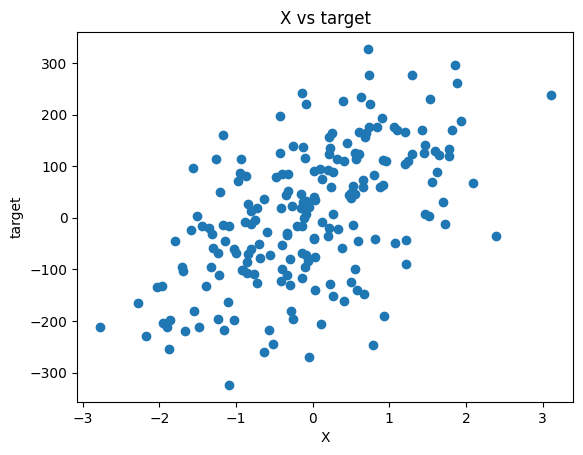

In [9]:
plt.scatter(X.x1, y)
plt.xlabel('X')
plt.ylabel('target')
plt.title('X vs target')
plt.show()



c)

In [10]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

d)e)

In [11]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[77.28,88.08,71.98,28.67,31.59]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['x1','x2','x3','x4','x5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3475
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [12]:
linear_model_pred = linear_model.predict(X_val)
linear_rmse = root_mean_squared_error(linear_model_pred, y_val)
print(linear_rmse)

3.592300959691065


In [13]:
tree_model = DecisionTreeRegressor()
tree_hyperparams = {
    'max_depth': [None, 2,5,8,14],
    'min_samples_leaf': [2,5,7,10]
}
tree_gs = GridSearchCV(
    tree_model,
    tree_hyperparams,
    cv = 5,
    scoring="neg_mean_squared_error",
)

tree_gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 2, ...], 'min_samples_leaf': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosit

In [14]:
tree_gs_pred = tree_gs.predict(X_val)
tree_rmse = root_mean_squared_error(tree_gs_pred, y_val)
print(tree_rmse)

90.9086094543299


In [15]:
print(y_val.std())
print(y_val.mean())

122.66806159456117
9.720720024563745


In [16]:
print(tree_gs.best_params_)
pd.DataFrame(tree_gs.cv_results_)

{'max_depth': 8, 'min_samples_leaf': 7}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003269,0.000526,0.002231,0.000181,None,2,"{'max_depth': None, 'min_samples_leaf': 2}",-12477.533761,-6373.235306,-11227.769572,-10085.691862,-10017.588755,-10036.363851,2039.610483,9
1,0.002273,0.000139,0.001899,0.000355,None,5,"{'max_depth': None, 'min_samples_leaf': 5}",-11551.879964,-6638.536131,-9158.236939,-10619.572353,-11274.988060,-9848.642689,1806.170263,6
2,0.002449,0.000344,0.001600,0.000060,None,7,"{'max_depth': None, 'min_samples_leaf': 7}",-10723.497533,-5454.218703,-7184.453799,-8400.925807,-10626.807096,-8477.980587,2023.960802,3
3,0.002080,0.000208,0.001672,0.000275,None,10,"{'max_depth': None, 'min_samples_leaf': 10}",-13371.851976,-8325.695754,-10534.801453,-9700.285999,-11642.240339,-10714.975104,1714.031964,13
4,0.002239,0.000344,0.001700,0.000212,2,2,"{'max_depth': 2, 'min_samples_leaf': 2}",-17657.014833,-13514.374022,-12947.199328,-16209.989218,-11531.968519,-14372.109184,2236.107549,19
5,0.002201,0.000217,0.001787,0.000222,2,5,"{'max_depth': 2, 'min_samples_leaf': 5}",-17657.014833,-13514.374022,-12947.199328,-16209.989218,-11531.968519,-14372.109184,2236.107549,19
6,0.002308,0.000524,0.001657,0.000144,2,7,"{'max_depth': 2, 'min_samples_leaf': 7}",-17657.014833,-12083.718242,-12947.199328,-16209.989218,-11531.968519,-14085.978028,2412.158915,17
7,0.002174,0.000320,0.001927,0.000505,2,10,"{'max_depth': 2, 'min_samples_leaf': 10}",-17657.014833,-12083.718242,-12272.559579,-16178.634814,-13494.567787,-14337.299051,2211.922322,18
8,0.002157,0.000089,0.001602,0.000125,5,2,"{'max_depth': 5, 'min_samples_leaf': 2}",-12644.827658,-8183.559848,-10362.238417,-9367.454576,-11766.422013,-10464.900502,1604.087460,12
9,0.002259,0.000277,0.001824,0.000339,5,5,"{'max_depth': 5, 'min_samples_leaf': 5}",-11426.385116,-6939.114273,-8023.797640,-11039.711024,-9908.286736,-9467.458958,1730.917805,5


f)

In [17]:
best_model = linear_model
best_model.fit(X_train_full, y_train_full)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[77.3 ,87.95,71.89,28.57,31.61]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['x1','x2','x3','x4','x5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1593
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [18]:
best_model_pred = best_model.predict(X_test)
best_model_rmse = root_mean_squared_error(best_model_pred, y_test)
print(best_model_rmse)

3.371549077515551


h)

In [19]:
best_model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[77.24,87.85,71.77,28.45,31.66]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['x1','x2','x3','x4','x5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1269
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [20]:
predictions = best_model.predict(X)

Text(0.5, 1.0, 'predicted vs actual')

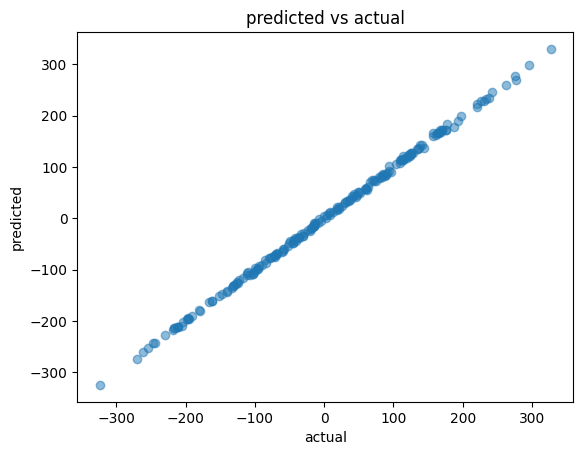

In [21]:
plt.scatter(y, predictions, alpha=0.5)
plt.xlabel("actual")
plt.ylabel("predicted")
plt.title('predicted vs actual')

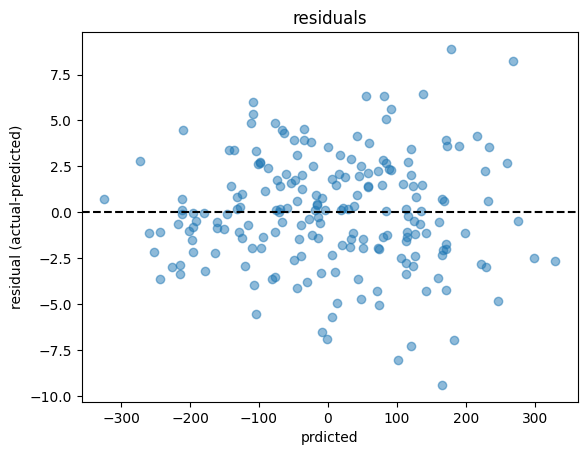

In [22]:
residuals = y-predictions

plt.scatter(predictions, residuals, alpha=0.5)
plt.xlabel('prdicted')
plt.ylabel('residual (actual-predicted)')
plt.title('residuals')
plt.axhline(0, color='black', linestyle='--')

In [23]:
pd.DataFrame({'actual': y[:10], 'predicted': predictions[:10]}).round(1)

,actual,predicted
0,220.2,223.0
1,175.9,171.9
2,-162.3,-161.4
3,165.9,165.2
4,43.3,48.0
5,-12.7,-12.1
6,-43.1,-41.7
7,110.1,108.6
8,-195.6,-195.6
9,156.6,166.0


uppgift_10

a)

In [24]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor

In [25]:
df = pd.read_csv('salary_dataset.csv')

In [26]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [28]:
X = df[['YearsExperience']]
y = df['Salary']

Text(0, 0.5, 'salary')

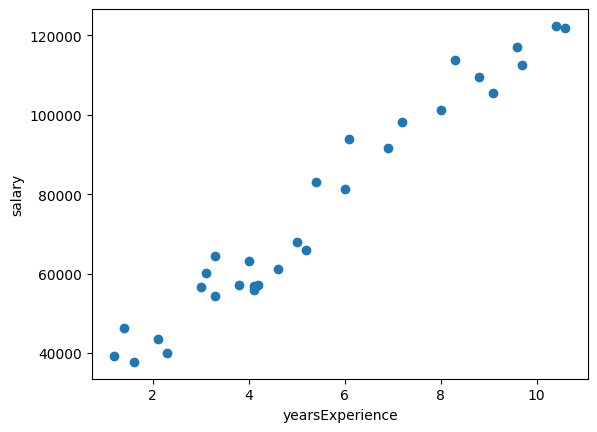

In [29]:
plt.scatter(X,y)
plt.xlabel('yearsExperience')
plt.ylabel('salary')

d)

In [30]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
linear_model = LinearRegression()
linear_cv = cross_validate(
    linear_model,
    X_train_full,
    y_train_full,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
linear_cv_scores = linear_cv['test_score']
print(linear_cv_scores)
print(linear_cv_scores.mean())

[-4550.08341777 -6393.62938648 -5697.35170249 -1868.75051151
 -7956.20096673]
-5293.203196998775


In [32]:
linear_model.fit(X_train_full,y_train_full)
linear_model_pred = linear_model.predict(X_test)
linear_model_rmse = root_mean_squared_error(linear_model_pred,y_test)
print(linear_model_rmse)

7059.043621901506


In [33]:
tree_model = DecisionTreeRegressor()
tree_model_cv = cross_validate(
    tree_model,
    X_train_full,
    y_train_full,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

tree_model_scores= tree_model_cv['test_score']
print(tree_model_scores)
print(tree_model_scores.mean())


[-3917.3902282  -3067.10201982 -4907.39380935 -8524.87312516
 -7641.13373869]
-5611.57858424216


In [34]:
tree_model.fit(X_train_full,y_train_full)
tree_model_pred = tree_model.predict(X_test)
tree_model_rmse = root_mean_squared_error(tree_model_pred,y_test)
print(tree_model_rmse)

10052.248993799016


In [35]:
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5)
elastic_model_cv = cross_validate(
    elastic_model,
    X_train_full,
    y_train_full,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

elastic_model_scores = elastic_model_cv['test_score']
print(elastic_model_scores)
print(elastic_model_scores.mean())


[-5680.05108636 -6676.75836871 -4980.79855528 -3092.30525001
 -7890.95334578]
-5664.17332122904


In [36]:
elastic_model.fit(X_train_full,y_train_full)
elastic_model_pred = elastic_model.predict(X_test)
elastic_model_rmse = root_mean_squared_error(elastic_model_pred, y_test)
print(elastic_model_rmse)

7279.675009537165


d)


In [37]:
best_model = linear_model

uppgift_11


In [38]:
import seaborn as sns


In [39]:
df = sns.load_dataset("mpg")
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [41]:
df = df.dropna()

In [42]:
df = df.drop(columns="name")

In [43]:
df = pd.get_dummies(df, columns=['origin'], drop_first=True)

In [44]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,False,True


In [45]:
X = df.drop(columns=['mpg'])
y = df[['mpg']]

In [46]:
X.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,8,307.0,130.0,3504,12.0,70,False,True
1,8,350.0,165.0,3693,11.5,70,False,True
2,8,318.0,150.0,3436,11.0,70,False,True
3,8,304.0,150.0,3433,12.0,70,False,True
4,8,302.0,140.0,3449,10.5,70,False,True


In [47]:
y.head()

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [48]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y, test_size=0.20, random_state=42)

In [49]:
linear_model = LinearRegression()
linear_model.fit(X_train_full,y_train_full)
linear_model_pred = linear_model.predict(X_test)

linear_model_rmse = root_mean_squared_error(linear_model_pred, y_test)

print(linear_model_rmse)

3.256114096847396
